In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

In [2]:
# dataset
train="dataset/Train"
test="dataset/Test"

In [3]:
#preprocessing of images for the training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_datagen=ImageDataGenerator(  # a tool that creates batches of images for training
    shear_range=0.2,  # tilts images slightly to make the model robust
    zoom_range=0.2,   # randomly zoom in/out on images
    horizontal_flip=True)  #flips the image left or right

In [5]:
test_datagen=ImageDataGenerator()

In [6]:
train_data=train_datagen.flow_from_directory(  # reads images directly from folders
    train,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary')

test_data=test_datagen.flow_from_directory(  # reads images directly from folders
    test,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary')

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [7]:
# build a CNN model

model=models.Sequential([
    layers.Input(shape=(150,150,3)),
    layers.Conv2D(32,(3,3),activation='relu'), 
                  
    layers.MaxPooling2D((2,2)),  
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')  #output
])

In [8]:
# COMPILE MODEL 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
#train the model
model.fit(
    train_data,
    epochs=10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.5138 - loss: 49.0205 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.5888 - loss: 0.6795
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.5713 - loss: 0.6762
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.5888 - loss: 0.6501
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.6587 - loss: 0.6212
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.6675 - loss: 0.6122
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.6463 - loss: 0.6265
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.6463 - loss: 0.6256
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.6725 - loss: 0.5953
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.7038 - loss: 0.5563


In [10]:
import matplotlib.pyplot as plt

In [11]:
from PIL import Image

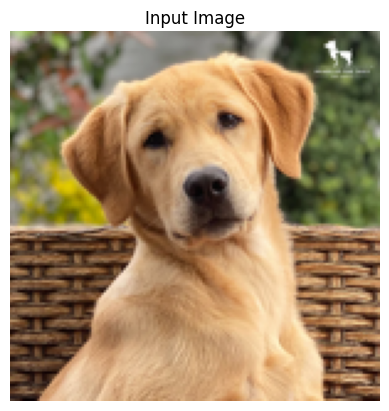

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
🐱 Cat (57.38%)


In [12]:
def predict_image(path):

    img = Image.open(path).convert("RGB").resize((150,150))
    
    img = np.array(img)
    img = img.reshape(1,150,150,3)


    plt.imshow(img[0])
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    
    pred = model.predict(img)[0][0]

    confidence = pred * 100

    if pred > 0.5:
        print(f"🐶 Dog ({confidence:.2f}%)")
    else:
        print(f"🐱 Cat ({100-confidence:.2f}%)")


predict_image("dog.jpg")